In [1]:
# ============================================================
# 02_traditional_clustering.py
# Traditional clustering — CD and UC
# Methods: K-means, Ward, PAM, HDBSCAN, Consensus
# ============================================================

import numpy as np
import pandas as pd
from sklearn.cluster import (
    KMeans, AgglomerativeClustering)
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import hdbscan
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist, squareform
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')
import os

PROJECT_DIR  = '/rds/homes/j/jxt554'
DATA_DIR     = f'{PROJECT_DIR}/data'
FIGURES_DIR  = f'{PROJECT_DIR}/figures'
TABLES_DIR   = f'{PROJECT_DIR}/tables'
SEED         = 42
K_RANGE      = [2, 3, 4, 5]

for d in [DATA_DIR, FIGURES_DIR, TABLES_DIR]:
    os.makedirs(d, exist_ok=True)

print('TRADITIONAL CLUSTERING PIPELINE')
print('='*55)
print('Methods: K-means | Ward | PAM | '
      'HDBSCAN | Consensus')
print(f'K range: {K_RANGE}')

# Load data
X_cd = np.load(f'{DATA_DIR}/X_cd_int.npy')
X_uc = np.load(f'{DATA_DIR}/X_uc_int.npy')
meta_cd = pd.read_csv(
    f'{DATA_DIR}/meta_cd_sampleqc.csv')
meta_uc = pd.read_csv(
    f'{DATA_DIR}/meta_uc_sampleqc.csv')

print(f'\nCD: {X_cd.shape}')
print(f'UC: {X_uc.shape}')

TRADITIONAL CLUSTERING PIPELINE
Methods: K-means | Ward | PAM | HDBSCAN | Consensus
K range: [2, 3, 4, 5]

CD: (215, 991)
UC: (430, 991)


In [2]:
# ── Helper functions ──────────────────────────────
def get_metrics(X, labels):
    '''Compute clustering quality metrics'''
    n_clusters = len(np.unique(labels))
    if n_clusters < 2:
        return {'sil':np.nan,
                'ch':np.nan,
                'db':np.nan}
    return {
        'sil': silhouette_score(X, labels),
        'ch' : calinski_harabasz_score(
                   X, labels),
        'db' : davies_bouldin_score(
                   X, labels),
    }

def pam_cluster(X, k, seed=SEED):
    '''
    PAM via k-medoids
    Uses sklearn_extra if available
    Falls back to manual implementation
    '''
    try:
        from sklearn_extra.cluster import KMedoids
        pam = KMedoids(
            n_clusters=k,
            random_state=seed,
            method='fasterpam')
        return pam.fit_predict(X)
    except ImportError:
        # Manual PAM fallback
        np.random.seed(seed)
        n = len(X)
        # Initialise medoids randomly
        medoid_idx = np.random.choice(
            n, k, replace=False)
        for _ in range(100):
            # Assign to nearest medoid
            dists = np.array([
                np.linalg.norm(X - X[m], axis=1)
                for m in medoid_idx])
            labels = np.argmin(dists, axis=0)
            # Update medoids
            new_medoids = []
            for c in range(k):
                cluster = np.where(
                    labels==c)[0]
                if len(cluster)==0:
                    new_medoids.append(
                        medoid_idx[c])
                    continue
                # Find point minimising
                # total distance within cluster
                sub = X[cluster]
                d   = squareform(
                    pdist(sub))
                new_medoids.append(
                    cluster[np.argmin(
                        d.sum(axis=1))])
            if new_medoids == list(medoid_idx):
                break
            medoid_idx = new_medoids
        return labels

print('Helper functions defined ✓')

Helper functions defined ✓


In [3]:
# ── Main clustering function ──────────────────────
def run_clustering(X, meta, cohort_label):
    print(f'\n{"="*55}')
    print(f'{cohort_label} CLUSTERING')
    print(f'{"="*55}')
    print(f'Matrix: {X.shape}')

    results  = []
    all_labels = {}

    # PCA for visualisation (2D)
    pca2  = PCA(n_components=2,
                 random_state=SEED)
    X_pca = pca2.fit_transform(X)
    var2  = pca2.explained_variance_ratio_*100

    # ── 1. K-means ────────────────────────────────
    print(f'\n--- 1. K-MEANS ---')
    km_results = []
    for k in K_RANGE:
        km  = KMeans(n_clusters=k,
                      random_state=SEED,
                      n_init=50,
                      max_iter=500)
        lbl = km.fit_predict(X)
        met = get_metrics(X, lbl)
        km_results.append({
            'method':'K-means','k':k,
            **met, 'inertia':km.inertia_})
        all_labels[f'kmeans_k{k}'] = lbl
        print(f'  k={k}: sil={met["sil"]:.4f} '
              f'db={met["db"]:.4f} '
              f'inertia={km.inertia_:.0f}')

    # ── 2. Ward hierarchical ──────────────────────
    print(f'\n--- 2. WARD HIERARCHICAL ---')
    # Full dendrogram
    linkage = sch.linkage(X, method='ward')
    ward_results = []
    for k in K_RANGE:
        lbl = sch.fcluster(
            linkage, k, criterion='maxclust')-1
        met = get_metrics(X, lbl)
        ward_results.append({
            'method':'Ward','k':k,**met})
        all_labels[f'ward_k{k}'] = lbl
        print(f'  k={k}: sil={met["sil"]:.4f} '
              f'db={met["db"]:.4f}')

    # ── 3. PAM ────────────────────────────────────
    print(f'\n--- 3. PAM ---')
    pam_results = []
    for k in K_RANGE:
        lbl = pam_cluster(X, k)
        met = get_metrics(X, lbl)
        pam_results.append({
            'method':'PAM','k':k,**met})
        all_labels[f'pam_k{k}'] = lbl
        print(f'  k={k}: sil={met["sil"]:.4f} '
              f'db={met["db"]:.4f}')

    # ── 4. HDBSCAN ────────────────────────────────
    print(f'\n--- 4. HDBSCAN ---')
    hdb_results = []
    best_hdb_sil = -1
    best_hdb_lbl = None
    best_hdb_cfg = None

    for mcs in [5, 8, 10, 15, 20]:
        for ms in [3, 5, 8]:
            hdb = hdbscan.HDBSCAN(
                min_cluster_size=mcs,
                min_samples=ms,
                metric='euclidean')
            lbl = hdb.fit_predict(X)
            n_noise   = (lbl==-1).sum()
            n_clusters = len(
                set(lbl)) - (
                1 if -1 in lbl else 0)
            if (n_noise/len(X) > 0.15 or
                    n_clusters < 2):
                continue
            mask = lbl != -1
            sil  = silhouette_score(
                X[mask], lbl[mask])
            hdb_results.append({
                'mcs':mcs,'ms':ms,
                'n_clusters':n_clusters,
                'n_noise':n_noise,
                'sil':sil})
            if sil > best_hdb_sil:
                best_hdb_sil = sil
                best_hdb_lbl = lbl.copy()
                best_hdb_cfg = (mcs, ms,
                                 n_clusters)

    if best_hdb_lbl is not None:
        all_labels['hdbscan'] = best_hdb_lbl
        print(f'  Best: mcs={best_hdb_cfg[0]} '
              f'ms={best_hdb_cfg[1]} '
              f'k={best_hdb_cfg[2]} '
              f'sil={best_hdb_sil:.4f}')
        print(f'  Noise: '
              f'{(best_hdb_lbl==-1).sum()} '
              f'patients')
    else:
        print('  No valid HDBSCAN solution found')

    # ── 5. Consensus clustering ───────────────────
    print(f'\n--- 5. CONSENSUS CLUSTERING ---')
    consensus_results = {}
    N = len(X)

    for k in K_RANGE:
        print(f'  k={k}: running 100 iterations...',
               end=' ', flush=True)
        M = np.zeros((N, N))
        I = np.zeros((N, N))

        for it in range(100):
            np.random.seed(it)
            # Subsample 80% of patients
            idx = np.random.choice(
                N, int(0.8*N), replace=False)
            # Count co-sampled pairs
            for i in idx:
                for j in idx:
                    I[i,j] += 1

            # Cluster subsample
            sub = X[idx]
            km  = KMeans(n_clusters=k,
                          random_state=it,
                          n_init=10)
            lbl_sub = km.fit_predict(sub)

            # Count co-clustered pairs
            for ci in range(k):
                pts = idx[lbl_sub==ci]
                for i in pts:
                    for j in pts:
                        M[i,j] += 1

        # Consensus matrix
        C = np.divide(
            M, I,
            out=np.zeros_like(M),
            where=I!=0)
        np.fill_diagonal(C, 1.0)

        # Cluster consensus matrix
        dist = 1 - C
        np.fill_diagonal(dist, 0)
        lk   = sch.linkage(
            squareform(dist),
            method='average')
        lbl_c = sch.fcluster(
            lk, k,
            criterion='maxclust') - 1
        sil_c = silhouette_score(
            dist, lbl_c,
            metric='precomputed')

        # Stability
        stab = np.array([
            C[i, lbl_c==lbl_c[i]].mean()
            for i in range(N)])

        consensus_results[k] = {
            'matrix'   : C,
            'labels'   : lbl_c,
            'sil'      : sil_c,
            'stability': stab.mean(),
            'unstable' : (stab<0.5).sum(),
        }
        all_labels[f'consensus_k{k}'] = lbl_c
        print(f'sil={sil_c:.4f} '
              f'stab={stab.mean():.4f} '
              f'unstable='
              f'{(stab<0.5).sum()}')

    # ── K selection summary ───────────────────────
    print(f'\nK SELECTION SUMMARY:')
    print(f'{"Method":<15} '
          + ''.join([f'{"k="+str(k):>10}'
                      for k in K_RANGE]))
    print('-'*55)

    for method, res_list in [
        ('K-means', km_results),
        ('Ward',    ward_results),
        ('PAM',     pam_results),
    ]:
        sils = [r['sil'] for r in res_list]
        print(f'{method:<15} '
              + ''.join([f'{s:>10.4f}'
                          for s in sils]))

    print(f'{"Consensus":<15} '
          + ''.join([
              f'{consensus_results[k]["sil"]:>10.4f}'
              for k in K_RANGE]))

    # Best k per method
    best_km   = K_RANGE[np.argmax(
        [r['sil'] for r in km_results])]
    best_ward = K_RANGE[np.argmax(
        [r['sil'] for r in ward_results])]
    best_cons = max(
        consensus_results,
        key=lambda k:
        consensus_results[k]['sil'])

    print(f'\nBest k — K-means   : {best_km}')
    print(f'Best k — Ward      : {best_ward}')
    print(f'Best k — Consensus : {best_cons} '
          f'(sil='
          f'{consensus_results[best_cons]["sil"]:.4f}'
          f' stab='
          f'{consensus_results[best_cons]["stability"]:.4f})')

    # ── ARI comparison ────────────────────────────
    print(f'\nARI COMPARISON (k={best_km}):')
    ref_lbl = all_labels[f'kmeans_k{best_km}']
    for name, key in [
        ('Ward',      f'ward_k{best_km}'),
        ('PAM',       f'pam_k{best_km}'),
        ('Consensus', f'consensus_k{best_km}'),
    ]:
        if key in all_labels:
            ari = adjusted_rand_score(
                ref_lbl, all_labels[key])
            print(f'  K-means vs {name}: '
                  f'ARI={ari:.4f}')

    # Save results
    all_res = (km_results + ward_results +
                pam_results)
    pd.DataFrame(all_res).to_csv(
        f'{TABLES_DIR}/'
        f'traditional_clustering_'
        f'{cohort_label.lower()}.csv',
        index=False)

    cons_summary = pd.DataFrame([{
        'k': k,
        'sil': consensus_results[k]['sil'],
        'stability': consensus_results[k][
            'stability'],
        'unstable': consensus_results[k][
            'unstable'],
    } for k in K_RANGE])
    cons_summary.to_csv(
        f'{TABLES_DIR}/'
        f'consensus_summary_'
        f'{cohort_label.lower()}.csv',
        index=False)

    return (all_labels, consensus_results,
            linkage, X_pca, var2,
            best_km, best_cons)

In [4]:
# ── Run for CD ────────────────────────────────────
(cd_labels, cd_cons, cd_linkage,
 cd_pca, cd_var, cd_best_km,
 cd_best_cons) = run_clustering(
    X_cd, meta_cd, 'CD')

# ── Run for UC ────────────────────────────────────
(uc_labels, uc_cons, uc_linkage,
 uc_pca, uc_var, uc_best_km,
 uc_best_cons) = run_clustering(
    X_uc, meta_uc, 'UC')


CD CLUSTERING
Matrix: (215, 991)

--- 1. K-MEANS ---
  k=2: sil=0.1116 db=2.5205 inertia=191162
  k=3: sil=0.0910 db=2.6123 inertia=179848
  k=4: sil=0.0591 db=2.9004 inertia=172468
  k=5: sil=0.0563 db=3.0418 inertia=167632

--- 2. WARD HIERARCHICAL ---
  k=2: sil=0.0971 db=2.7046
  k=3: sil=0.0659 db=2.8406
  k=4: sil=0.0603 db=2.7022
  k=5: sil=0.0513 db=2.8808

--- 3. PAM ---
  k=2: sil=0.1041 db=2.6178
  k=3: sil=0.0649 db=3.1853
  k=4: sil=0.0556 db=3.4065
  k=5: sil=0.0502 db=3.2578

--- 4. HDBSCAN ---
  No valid HDBSCAN solution found

--- 5. CONSENSUS CLUSTERING ---
  k=2: running 100 iterations... sil=0.9136 stab=0.9347 unstable=1
  k=3: running 100 iterations... sil=0.7970 stab=0.8413 unstable=1
  k=4: running 100 iterations... sil=0.7194 stab=0.7927 unstable=4
  k=5: running 100 iterations... sil=0.5278 stab=0.6822 unstable=16

K SELECTION SUMMARY:
Method                 k=2       k=3       k=4       k=5
-------------------------------------------------------
K-means      

In [5]:
# ── Figures ───────────────────────────────────────
def make_figures(X_pca, var, all_labels,
                  consensus_results, linkage,
                  best_km, best_cons,
                  cohort, meta_df):

    PALETTE = {0:'#2E7D5B', 1:'#D97B2E',
               2:'#9467bd', 3:'#E24B4A'}
    N       = len(X_pca)

    fig = plt.figure(figsize=(22, 18))
    gs  = gridspec.GridSpec(
        3, 3, figure=fig,
        hspace=0.45, wspace=0.35)
    fig.patch.set_facecolor('white')

    # Panel 1: K-means PCA
    ax = fig.add_subplot(gs[0,0])
    ax.set_facecolor('#F8F9FA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    lbl = all_labels[f'kmeans_k{best_km}']
    for c in range(best_km):
        m = lbl==c
        ax.scatter(X_pca[m,0], X_pca[m,1],
                    c=PALETTE[c], s=25,
                    alpha=0.75, linewidths=0,
                    label=f'C{c+1} n={m.sum()}',
                    zorder=3)
    sil = silhouette_score(
        np.load(f'{DATA_DIR}/'
                f'X_{cohort.lower()}_int.npy'),
        lbl)
    ax.set_title(
        f'K-means k={best_km}\n'
        f'sil={sil:.4f}',
        fontsize=11, fontweight='700',
        loc='left')
    ax.set_xlabel(f'PC1 ({var[0]:.1f}%)',
                   fontsize=10)
    ax.set_ylabel(f'PC2 ({var[1]:.1f}%)',
                   fontsize=10)
    ax.legend(fontsize=8)

    # Panel 2: Ward PCA
    ax = fig.add_subplot(gs[0,1])
    ax.set_facecolor('#F8F9FA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    lbl = all_labels[f'ward_k{best_km}']
    for c in np.unique(lbl):
        m = lbl==c
        ax.scatter(X_pca[m,0], X_pca[m,1],
                    c=PALETTE[c%4], s=25,
                    alpha=0.75, linewidths=0,
                    label=f'C{c+1} n={m.sum()}',
                    zorder=3)
    sil = silhouette_score(
        np.load(f'{DATA_DIR}/'
                f'X_{cohort.lower()}_int.npy'),
        lbl)
    ax.set_title(
        f'Ward k={best_km}\nsil={sil:.4f}',
        fontsize=11, fontweight='700',
        loc='left')
    ax.set_xlabel(f'PC1 ({var[0]:.1f}%)',
                   fontsize=10)
    ax.set_ylabel(f'PC2 ({var[1]:.1f}%)',
                   fontsize=10)
    ax.legend(fontsize=8)

    # Panel 3: HDBSCAN PCA
    ax = fig.add_subplot(gs[0,2])
    ax.set_facecolor('#F8F9FA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if 'hdbscan' in all_labels:
        lbl = all_labels['hdbscan']
        unique = np.unique(lbl)
        for c in unique:
            m     = lbl==c
            color = '#CCCCCC' if c==-1 \
                    else PALETTE[c%4]
            label = ('Noise' if c==-1
                     else f'C{c+1} n={m.sum()}')
            ax.scatter(
                X_pca[m,0], X_pca[m,1],
                c=color, s=25, alpha=0.75,
                linewidths=0,
                label=label, zorder=3)
        ax.set_title('HDBSCAN (auto k)',
                      fontsize=11,
                      fontweight='700',
                      loc='left')
    else:
        ax.text(0.5, 0.5,
                 'No HDBSCAN solution',
                 ha='center', va='center',
                 transform=ax.transAxes)
        ax.set_title('HDBSCAN',
                      fontsize=11,
                      fontweight='700',
                      loc='left')
    ax.set_xlabel(f'PC1 ({var[0]:.1f}%)',
                   fontsize=10)
    ax.set_ylabel(f'PC2 ({var[1]:.1f}%)',
                   fontsize=10)
    ax.legend(fontsize=8)

    # Panel 4: Silhouette by k
    ax = fig.add_subplot(gs[1,0])
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2,
            linestyle='--', color='#ccc')
    ax.tick_params(length=0)

    k_vals = list(consensus_results.keys())
    for method, style, col in [
        ('K-means', 'o-', '#1B3A6B'),
        ('Ward',    's--','#C96A1F'),
        ('Consensus','D:', '#2E7D5B'),
    ]:
        key_map = {
            'K-means'  : 'kmeans',
            'Ward'     : 'ward',
            'Consensus': 'consensus',
        }
        km_tag = key_map[method]
        if km_tag == 'consensus':
            sils = [consensus_results[k]['sil']
                    for k in k_vals]
        else:
            sils = [
                silhouette_score(
                    np.load(
                        f'{DATA_DIR}/'
                        f'X_{cohort.lower()}_int.npy'),
                    all_labels[f'{km_tag}_k{k}'])
                for k in k_vals]
        ax.plot(k_vals, sils, style,
                 color=col, linewidth=2,
                 markersize=8, label=method,
                 zorder=3)

    ax.axvline(best_cons, color='#E24B4A',
                linestyle=':', linewidth=1.5,
                label=f'Best k={best_cons}')
    ax.set_xlabel('k', fontsize=11)
    ax.set_ylabel('Silhouette', fontsize=11)
    ax.set_xticks(k_vals)
    ax.set_title('Silhouette by k',
                  fontsize=11, fontweight='700',
                  loc='left')
    ax.legend(fontsize=8)

    # Panel 5: Consensus heatmap
    ax = fig.add_subplot(gs[1,1])
    lbl_c   = consensus_results[best_cons][
        'labels']
    sort_idx = np.argsort(lbl_c)
    C_sorted = consensus_results[best_cons][
        'matrix'][sort_idx][:,sort_idx]
    im = ax.imshow(C_sorted, cmap='Blues',
                    vmin=0, vmax=1,
                    aspect='auto')
    plt.colorbar(im, ax=ax,
                  label='Co-occurrence',
                  shrink=0.8)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(
        f'Consensus matrix k={best_cons}',
        fontsize=11, fontweight='700',
        loc='left')

    # Panel 6: Stability
    ax = fig.add_subplot(gs[1,2])
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2,
            linestyle='--', color='#ccc')
    k_vals_list = list(consensus_results.keys())
    stab_vals   = [
        consensus_results[k]['stability']
        for k in k_vals_list]
    unstab_vals = [
        consensus_results[k]['unstable']
        for k in k_vals_list]
    ax.bar(k_vals_list, stab_vals,
            color='#2E7D5B', alpha=0.85,
            edgecolor='white')
    ax.axhline(0.8, color='#E24B4A',
                linestyle='--', linewidth=1.5,
                label='0.8 threshold')
    ax.set_xlabel('k', fontsize=11)
    ax.set_ylabel('Mean stability',
                   fontsize=11)
    ax.set_xticks(k_vals_list)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.set_title('Consensus stability',
                  fontsize=11, fontweight='700',
                  loc='left')

    # Panel 7: Dendrogram
    ax = fig.add_subplot(gs[2,:])
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    sch.dendrogram(
        linkage, ax=ax,
        truncate_mode='lastp', p=30,
        leaf_font_size=8,
        color_threshold=(
            linkage[-best_km+1,2]
            if best_km>1 else 0),
        above_threshold_color='#CCCCCC')
    ax.set_title(
        f'Ward dendrogram — cut at k='
        f'{best_km}',
        fontsize=11, fontweight='700',
        loc='left')
    ax.set_ylabel('Distance', fontsize=10)
    ax.tick_params(axis='x', labelsize=7)

    plt.suptitle(
        f'{cohort} — traditional clustering\n'
        f'n={N} patients | '
        f'{X_cd.shape[1]} proteins | '
        f'Best k={best_cons} '
        f'(consensus sil='
        f'{consensus_results[best_cons]["sil"]:.4f})',
        fontsize=13, fontweight='800',
        y=1.01)
    plt.tight_layout()
    fname = (f'{FIGURES_DIR}/'
              f'traditional_clustering_'
              f'{cohort.lower()}.png')
    plt.savefig(fname, dpi=200,
                 bbox_inches='tight',
                 facecolor='white')
    plt.close()
    print(f'✓ Saved: '
          f'traditional_clustering_'
          f'{cohort.lower()}.png')

make_figures(cd_pca, cd_var, cd_labels,
              cd_cons, cd_linkage,
              cd_best_km, cd_best_cons,
              'CD', meta_cd)

make_figures(uc_pca, uc_var, uc_labels,
              uc_cons, uc_linkage,
              uc_best_km, uc_best_cons,
              'UC', meta_uc)

✓ Saved: traditional_clustering_cd.png
✓ Saved: traditional_clustering_uc.png



/rds/homes/j/jxt554/figures/traditional_clustering_cd.png (436 KB):


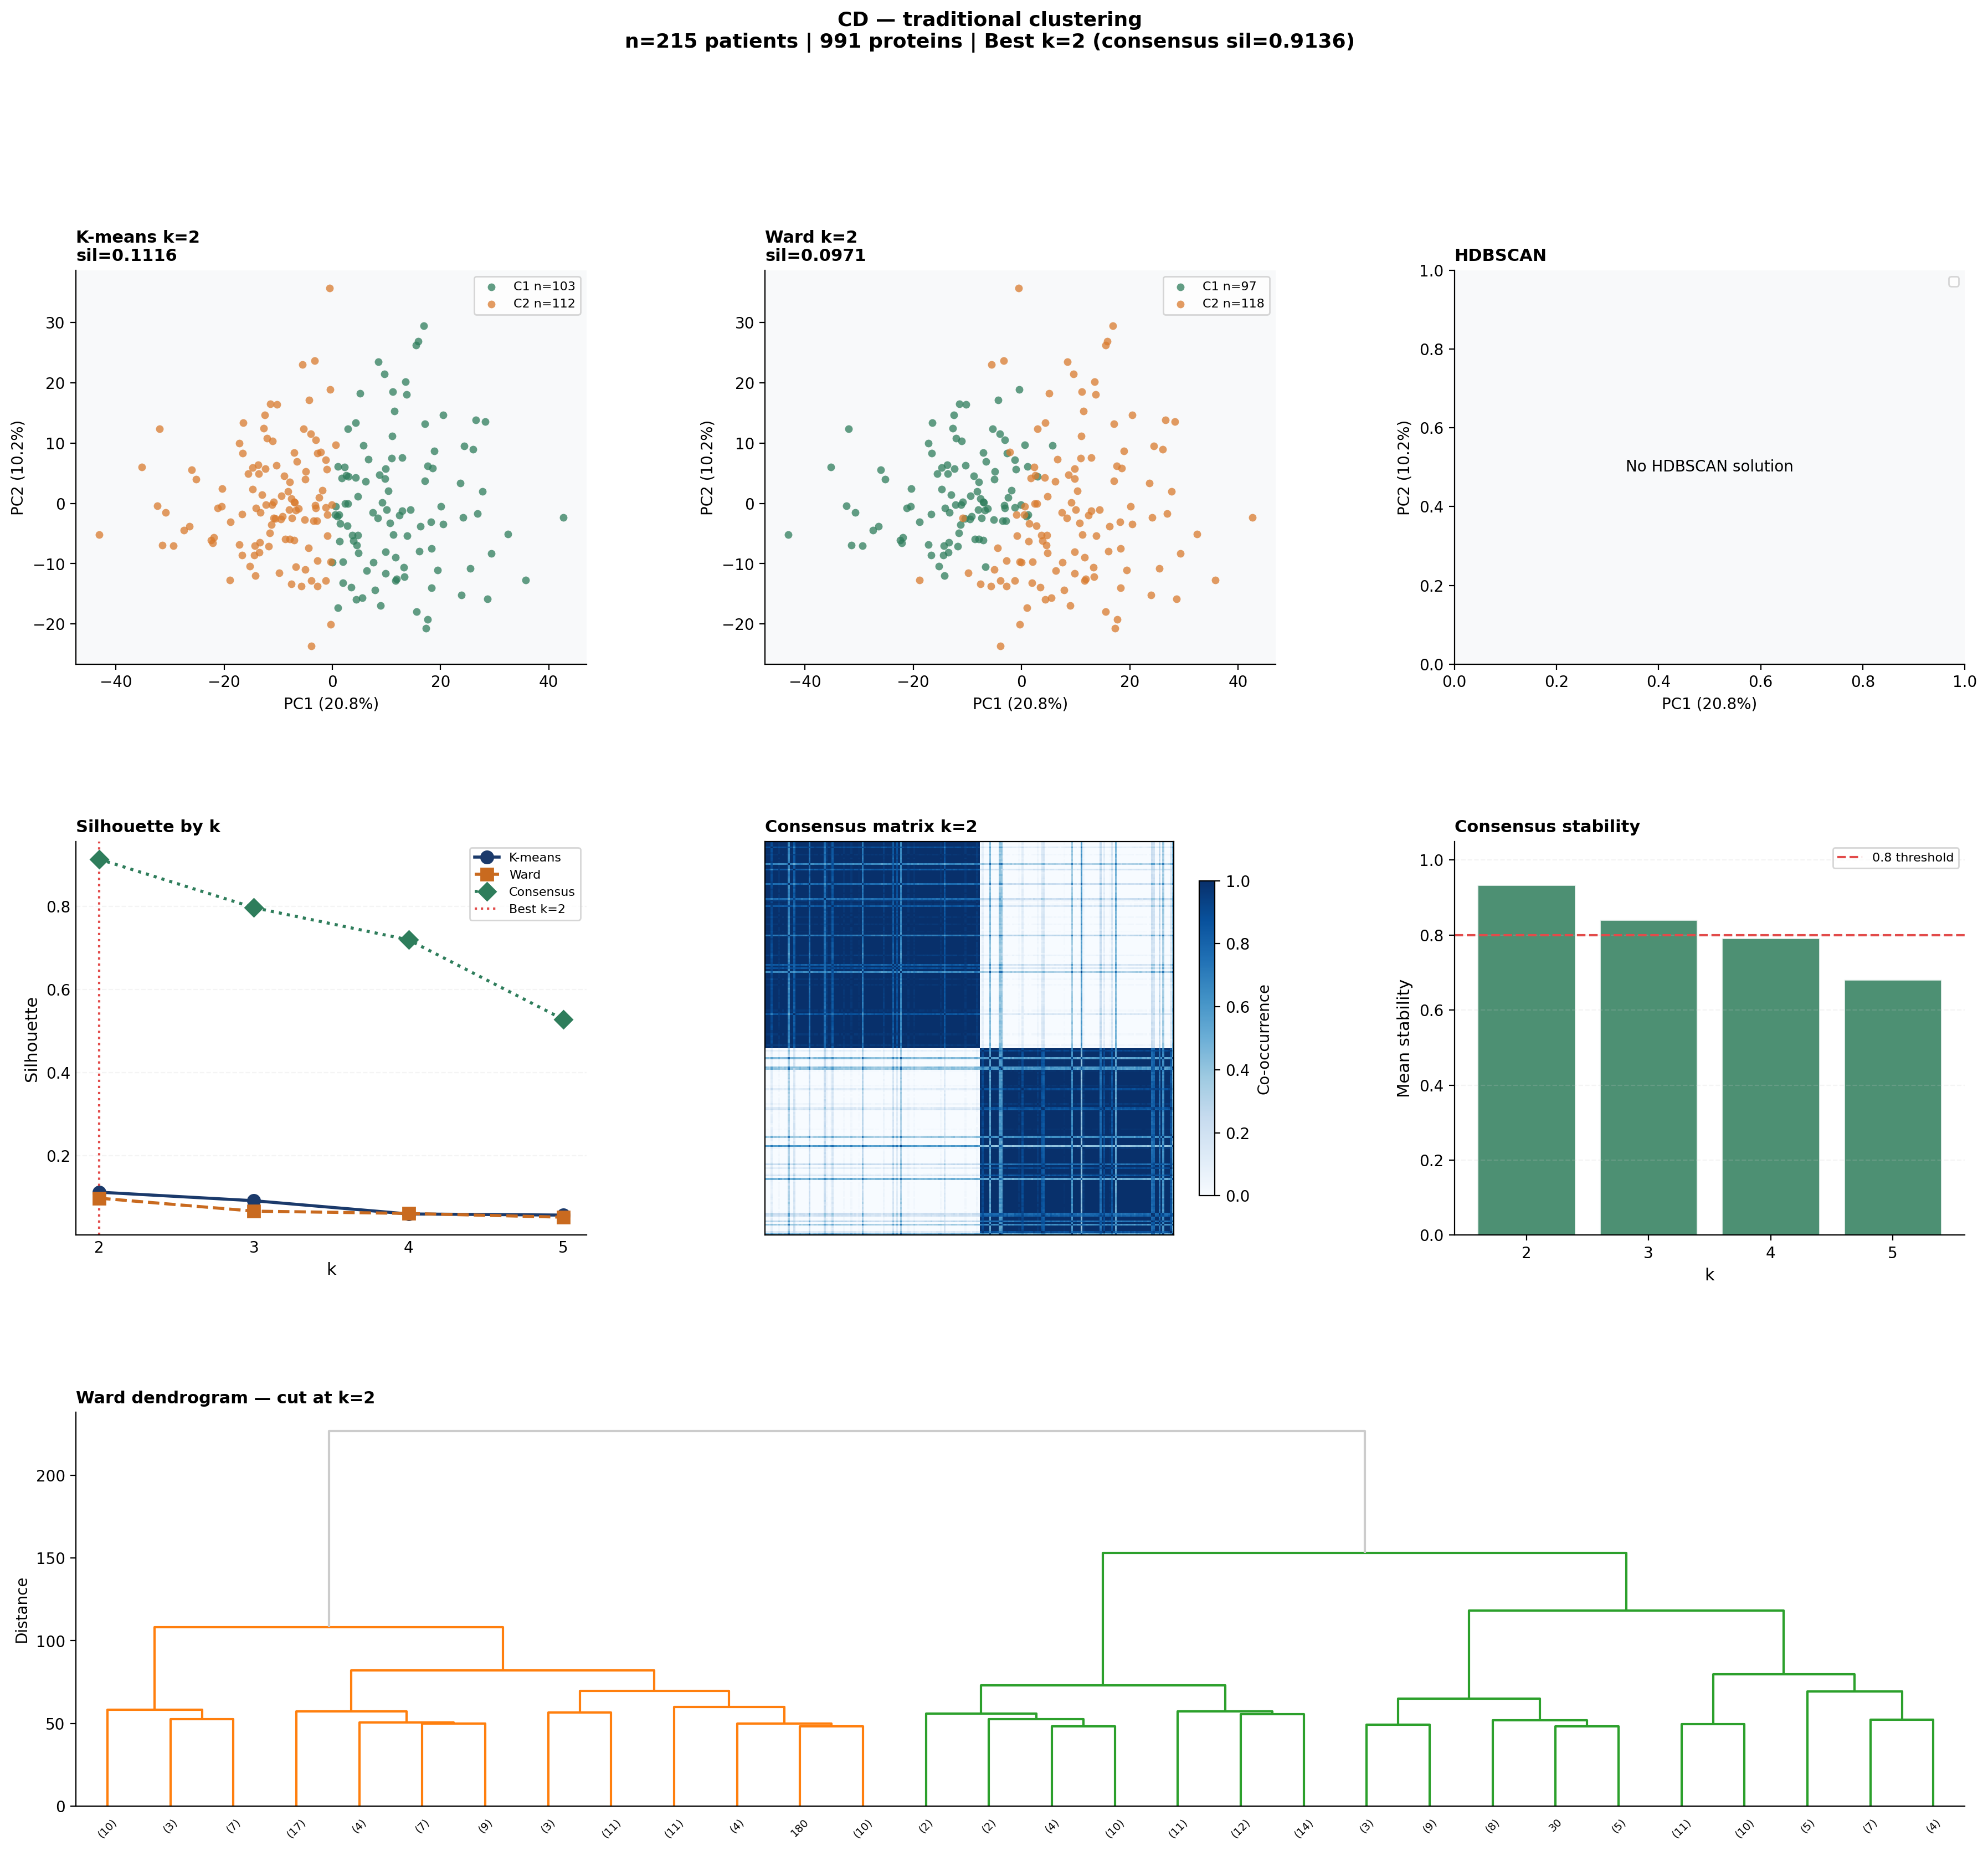


/rds/homes/j/jxt554/figures/traditional_clustering_uc.png (753 KB):


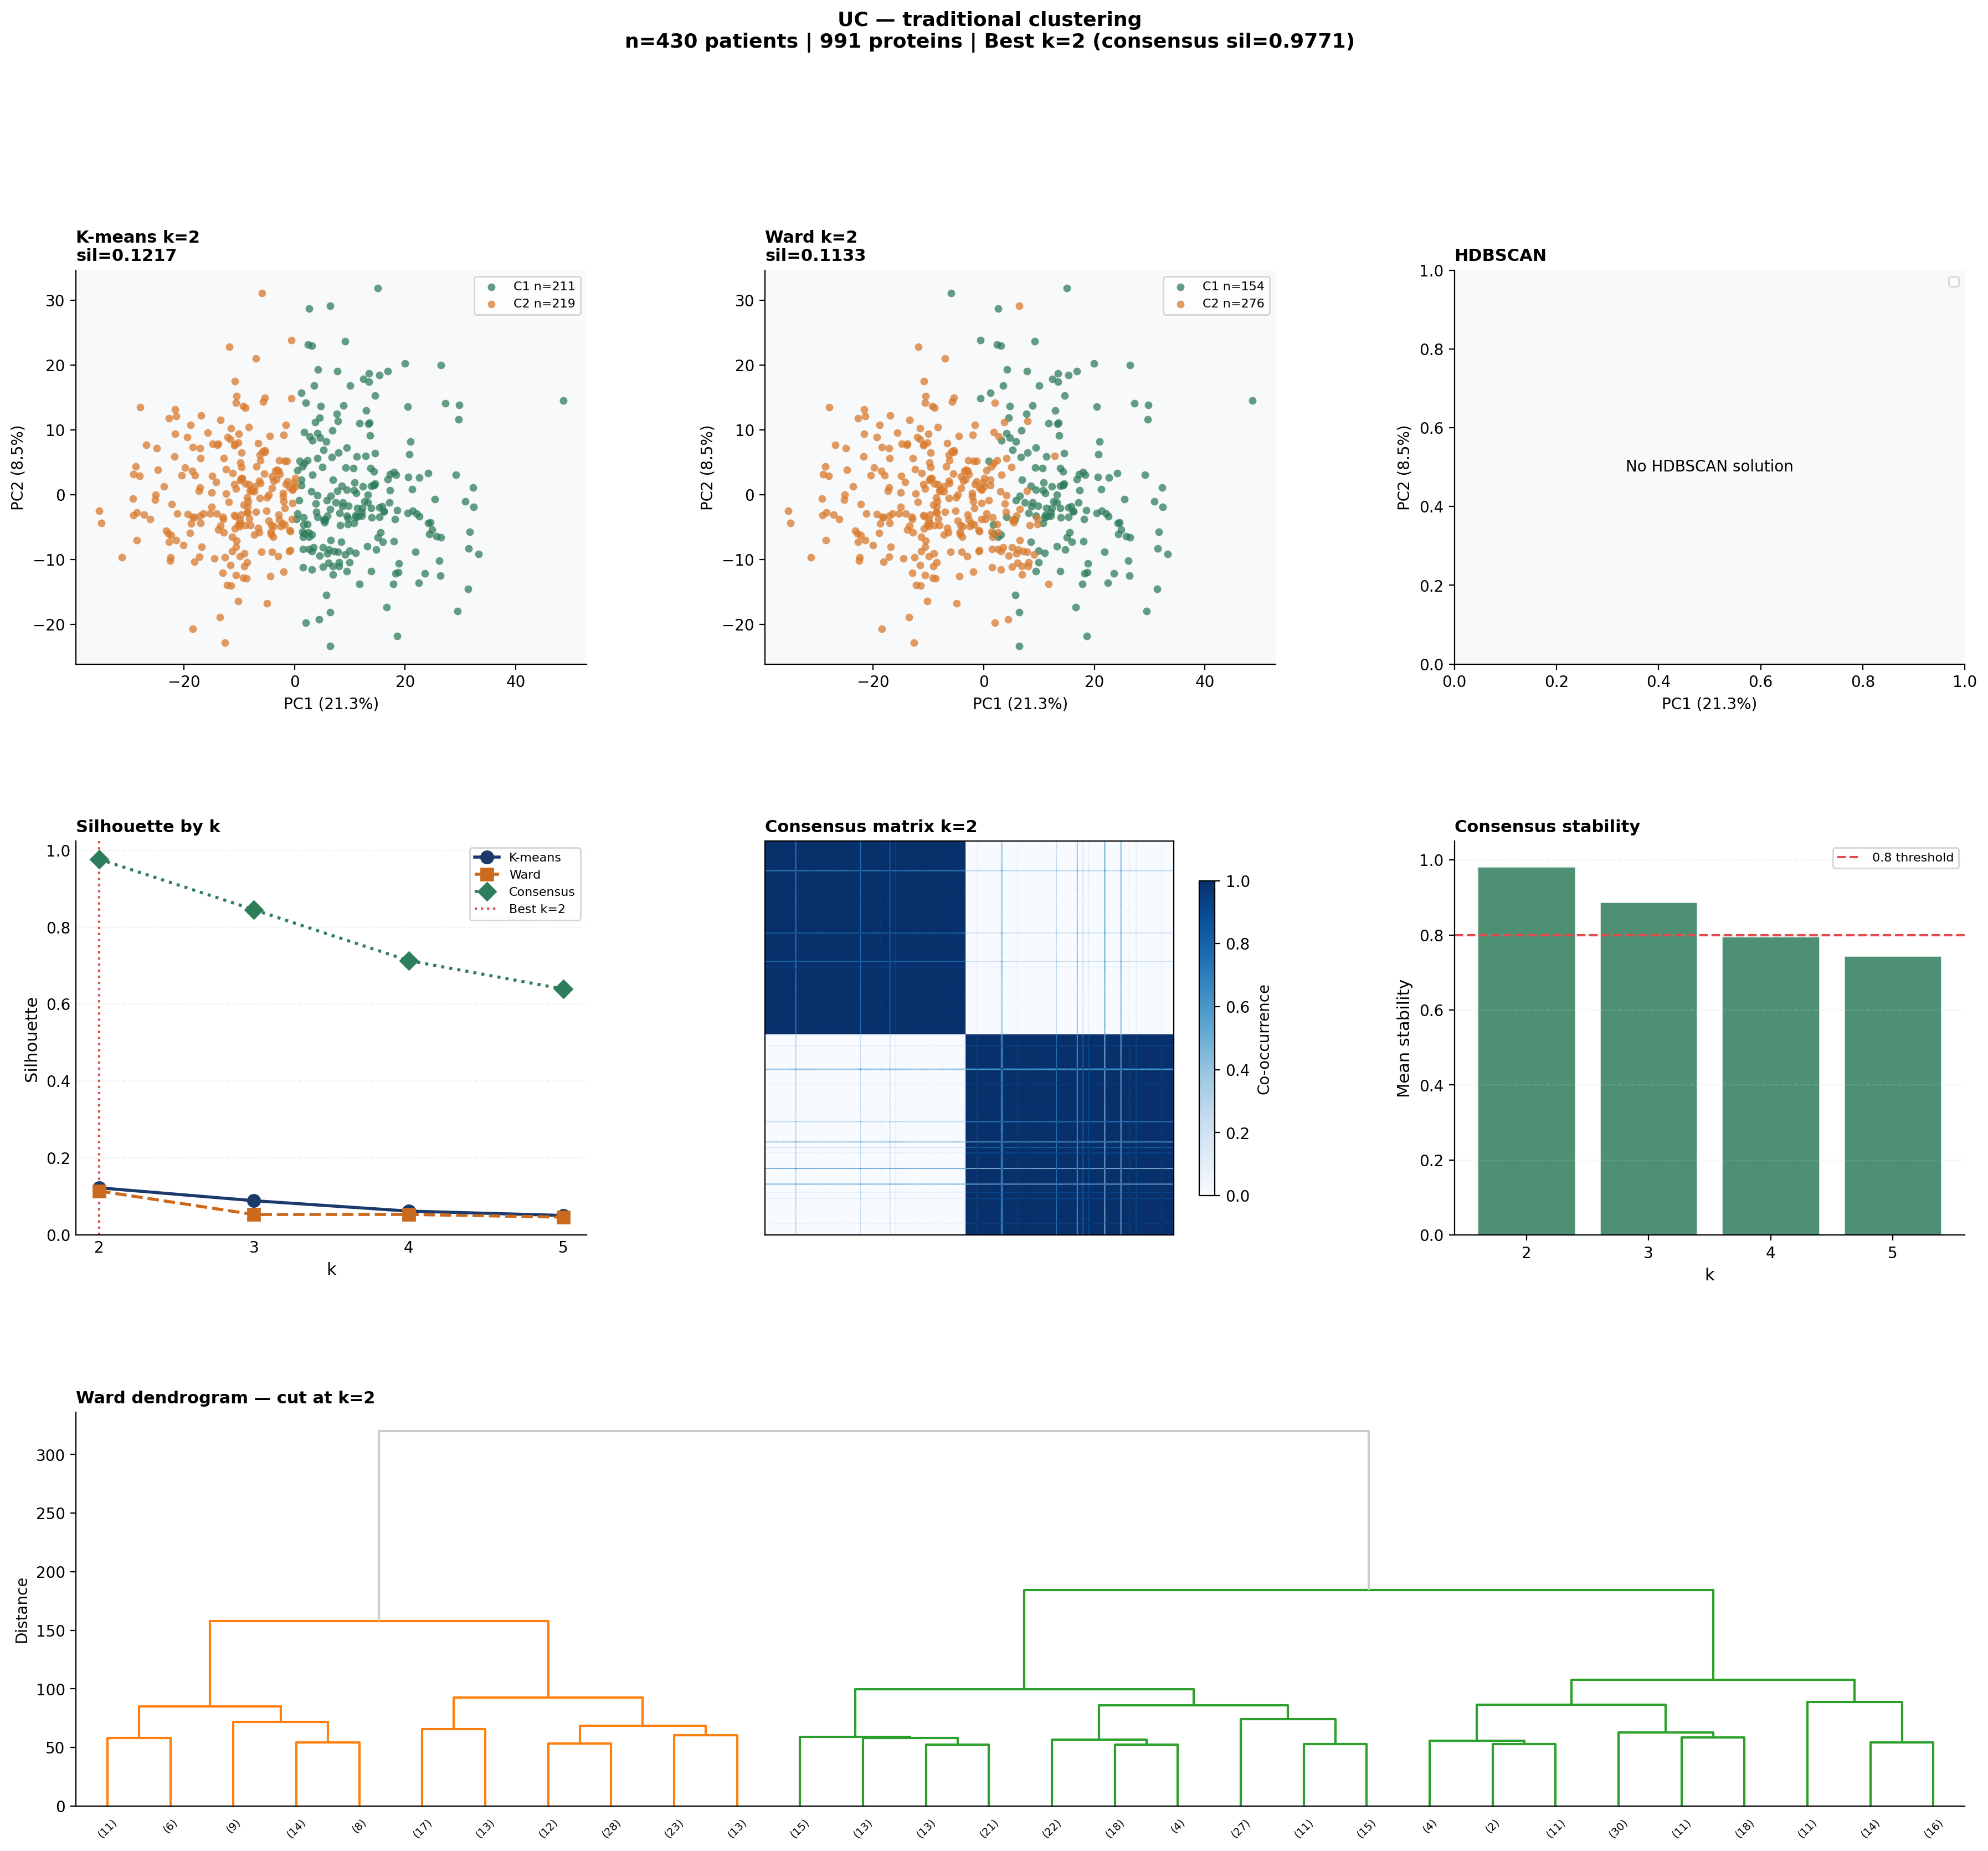


TRADITIONAL CLUSTERING COMPLETE

CD best k: 2 (consensus sil=0.9136)
UC best k: 2 (consensus sil=0.9771)

Next: 03_autoencoders.py (GPU)


In [6]:
# ── Display and summary ───────────────────────────
from IPython.display import Image, display

for cohort in ['cd','uc']:
    fname = (f'{FIGURES_DIR}/'
              f'traditional_clustering_'
              f'{cohort}.png')
    size  = os.path.getsize(fname)//1024
    print(f'\n{fname} ({size} KB):')
    display(Image(filename=fname, width=1000))

print('\n' + '='*55)
print('TRADITIONAL CLUSTERING COMPLETE')
print('='*55)
print(f'\nCD best k: {cd_best_cons} '
      f'(consensus sil='
      f'{cd_cons[cd_best_cons]["sil"]:.4f})')
print(f'UC best k: {uc_best_cons} '
      f'(consensus sil='
      f'{uc_cons[uc_best_cons]["sil"]:.4f})')
print('\nNext: 03_autoencoders.py (GPU)')

In [7]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100-SXM4-40GB


In [8]:
import numpy as np
import pandas as pd
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
import os
import json

PROJECT_DIR = '/rds/homes/j/jxt554'
DATA_DIR    = f'{PROJECT_DIR}/data'
TABLES_DIR  = f'{PROJECT_DIR}/tables'
SEED        = 42
K           = 2

X_cd = np.load(f'{DATA_DIR}/X_cd_int.npy')
X_uc = np.load(f'{DATA_DIR}/X_uc_int.npy')

print('UMAP GRID SEARCH')
print('='*55)

# Grid
N_NEIGHBORS  = [5, 10, 15, 20, 30]
MIN_DIST     = [0.0, 0.1, 0.25]
N_COMPONENTS = [2, 5, 10, 15]
METRICS      = ['euclidean', 'cosine']

total = (len(N_NEIGHBORS) *
          len(MIN_DIST) *
          len(N_COMPONENTS) *
          len(METRICS))
print(f'Configurations: {total}')

I0000 00:00:1783790544.170615  457599 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783790544.225676  457599 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783790560.926642  457599 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783790560.930648  457599 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.

UMAP GRID SEARCH
Configurations: 120


In [ ]:
def umap_grid_search(X, label):
    print(f'\n{label}: n={len(X)}')
    results  = []
    best_sil = -1
    best_emb = None
    best_cfg = None
    count    = 0

    for nn in N_NEIGHBORS:
        for md in MIN_DIST:
            for nc in N_COMPONENTS:
                for metric in METRICS:
                    count += 1
                    try:
                        reducer = umap.UMAP(
                            n_neighbors=nn,
                            min_dist=md,
                            n_components=nc,
                            metric=metric,
                            random_state=SEED)
                        emb = reducer.fit_transform(X)
                        km  = KMeans(
                            n_clusters=K,
                            random_state=SEED,
                            n_init=20)
                        lbl = km.fit_predict(emb)
                        sil = silhouette_score(
                            emb, lbl)
                        results.append({
                            'n_neighbors': nn,
                            'min_dist'   : md,
                            'n_components': nc,
                            'metric'     : metric,
                            'silhouette' : sil})
                        if sil > best_sil:
                            best_sil = sil
                            best_emb = emb.copy()
                            best_cfg = {
                                'n_neighbors': nn,
                                'min_dist'   : md,
                                'n_components': nc,
                                'metric'     : metric}
                        if count % 20 == 0:
                            print(f'  {count}/{total} '
                                  f'best={best_sil:.4f}')
                    except Exception as e:
                        pass

    res_df = pd.DataFrame(results).sort_values(
        'silhouette', ascending=False)
    print(f'\nTop 5 configs:')
    print(res_df.head(5).to_string(index=False))
    print(f'\nBest config: {best_cfg}')
    print(f'Best sil   : {best_sil:.4f}')

    return best_emb, best_cfg, best_sil, res_df

cd_emb, cd_cfg, cd_sil, cd_res = \
    umap_grid_search(X_cd, 'CD')
uc_emb, uc_cfg, uc_sil, uc_res = \
    umap_grid_search(X_uc, 'UC')


CD: n=215
  20/120 best=0.6944
  40/120 best=0.6944
  60/120 best=0.6944
  80/120 best=0.6944
  100/120 best=0.6944
  120/120 best=0.6944

Top 5 configs:
 n_neighbors  min_dist  n_components metric  silhouette
           5       0.0            10 cosine    0.694368
           5       0.0            15 cosine    0.675784
          10       0.0            15 cosine    0.667367
          20       0.0             2 cosine    0.665913
          15       0.0            10 cosine    0.665616

Best config: {'n_neighbors': 5, 'min_dist': 0.0, 'n_components': 10, 'metric': 'cosine'}
Best sil   : 0.6944

UC: n=430
  20/120 best=0.7297


In [ ]:
# Save UMAP results
np.save(f'{DATA_DIR}/X_cd_umap_best.npy',
         cd_emb)
np.save(f'{DATA_DIR}/X_uc_umap_best.npy',
         uc_emb)

with open(f'{DATA_DIR}/umap_cd_best_cfg.json',
           'w') as f:
    json.dump(cd_cfg, f, indent=2)
with open(f'{DATA_DIR}/umap_uc_best_cfg.json',
           'w') as f:
    json.dump(uc_cfg, f, indent=2)

cd_res.to_csv(
    f'{TABLES_DIR}/umap_grid_cd.csv',
    index=False)
uc_res.to_csv(
    f'{TABLES_DIR}/umap_grid_uc.csv',
    index=False)

print('\nUMAP GRID SEARCH COMPLETE')
print(f'CD best: {cd_cfg} sil={cd_sil:.4f}')
print(f'UC best: {uc_cfg} sil={uc_sil:.4f}')
print('\nNext: 03_autoencoders.py')